In [2]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('santander-customer-satisfaction')

print("Path to competition files:", path)

/home/thunderm/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to competition files: /home/thunderm/.cache/kagglehub/competitions/santander-customer-satisfaction


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
# Dataframe inicial
data_frame = pd.read_csv('train.csv')
data_frame.drop(columns=["ID"], inplace=True, errors="ignore")

In [3]:
# se arman las componentes con las que se trabaja
X = data_frame.drop(columns=['TARGET'])
Y = data_frame['TARGET']

In [4]:
# estandarizar para que el PCA funcione bien
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# se usa el PCA para que conserve el 95% de varianza
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

In [6]:
print("Varianza explicada por componente:", pca.explained_variance_ratio_)
print("Varianza acumulada:", np.cumsum(pca.explained_variance_ratio_))

Varianza explicada por componente: [0.08081681 0.05228942 0.03643922 0.0347879  0.03414537 0.03118406
 0.02941257 0.02824084 0.0260988  0.02561241 0.02254603 0.02132163
 0.02109872 0.02044335 0.01988033 0.01750806 0.01632033 0.01558424
 0.01390963 0.01322503 0.01291861 0.01234806 0.0122385  0.01180376
 0.01076219 0.01060324 0.01031092 0.01010785 0.00997737 0.00964378
 0.00951368 0.00935107 0.00914796 0.00873869 0.00846727 0.0080328
 0.00736512 0.00715435 0.00676614 0.00666676 0.00646893 0.00625363
 0.0062378  0.00607093 0.00600727 0.00598769 0.00581279 0.00577231
 0.00569488 0.00552525 0.00521108 0.00509327 0.00441738 0.00433953
 0.00418984 0.00411414 0.00407116 0.00390296 0.00382853 0.00371206
 0.00366313 0.00356299 0.00355273 0.00330976 0.00324125 0.0030927
 0.00302342 0.00298374 0.0029661  0.00294074 0.00283192 0.00278221
 0.00276757 0.00266071 0.00255625 0.00251915 0.00246486 0.00243229
 0.00237058 0.00228828 0.00227269 0.00221359 0.00218113 0.00216165
 0.00211946 0.00208768 0.0020

In [7]:
df_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])
print(df_pca.head())

        PC1       PC2       PC3        PC4       PC5       PC6       PC7  \
0 -2.673553 -1.554621 -0.222497  -0.268906  0.152867 -1.351671  0.155027   
1 -0.959710  7.752653 -4.195284  -5.224158  2.476887 -0.249987  0.125222   
2 -1.984764 -0.933970  0.011914   0.081934  0.112219  0.158695  0.013222   
3  4.443608 -1.455849  0.066270   0.082687 -0.193817  2.792661 -0.380519   
4  2.081770  8.542871  4.085268  10.280626 -5.907338 -1.590619 -0.253970   

        PC8       PC9      PC10  ...      PC91      PC92      PC93      PC94  \
0 -0.108121 -0.028993 -0.196237  ... -0.058400 -0.063759  0.218045  0.035817   
1  0.076464 -0.560343 -0.175361  ... -0.140630  0.643155  0.228847 -0.967780   
2 -0.113424  0.041161  0.069412  ... -0.074718 -0.061732 -0.311714 -0.041329   
3  0.131692  0.158738  0.294382  ... -0.105345 -0.505733 -0.393986 -0.292306   
4  0.782403 -0.519460  0.031622  ...  0.238651  0.221250  2.470108  0.154272   

       PC95      PC96      PC97      PC98      PC99     PC100 

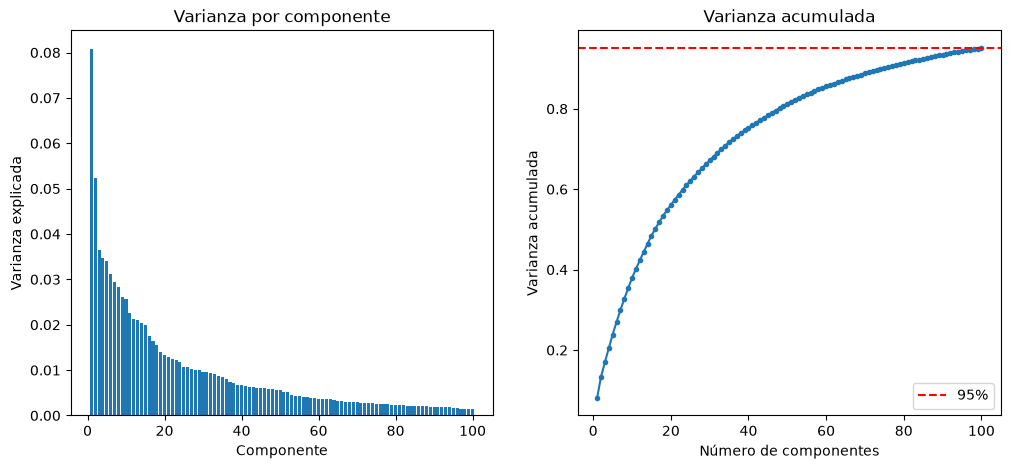

In [8]:
plt.figure(figsize=(12, 5))

# Varianza por componente
plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_)
plt.xlabel("Componente")
plt.ylabel("Varianza explicada")
plt.title("Varianza por componente")
plt.subplot(1, 2, 2)
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         np.cumsum(pca.explained_variance_ratio_), marker='o', markersize=3)
plt.axhline(y=0.95, color='r', linestyle='--', label='95%')
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.title("Varianza acumulada")
plt.legend()
plt.show()

In [ ]:
# Como el dataset viene ya repartido en train y test, 
# para entrenar y testear debemos repartir el dataset train.csv
# porque realmente el test.csv no aporta información que podamos usar.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split


# El 42 es muy repetido. 33550336 es un numero perfecto, y por probar quizá sale algo bueno
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=33550336, stratify=Y)

X_train_escalado = scaler.fit_transform(X_train)
X_test_escalado = scaler.fit_transform(X_test)

regresion_logistica = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=33550336)
regresion_logistica.fit(X_train_escalado, Y_train)
Y_prediccion = regresion_logistica.predict(X_test_escalado)
Y_probabilidad = regresion_logistica.predict_proba(X_test_escalado)[:, 1]

accuracy_sin_pca = accuracy_score(Y_test, Y_prediccion)
f1_sin_pca       = f1_score(Y_test, Y_prediccion)
auc_sin_pca      = roc_auc_score(Y_test, Y_probabilidad)

#--------
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_escalado)
X_test_pca = pca.transform(X_test_escalado)

regresion_logistica_pca = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=33550336)
regresion_logistica_pca.fit(X_train_pca, Y_train)
Y_prediccion_pca = regresion_logistica_pca.predict(X_test_pca)
Y_probabilidad_pca = regresion_logistica_pca.predict_proba(X_test_pca)[:, 1]

accuracy_con_pca = accuracy_score(Y_test, Y_prediccion_pca)
f1_con_pca       = f1_score(Y_test, Y_prediccion_pca)
auc_con_pca      = roc_auc_score(Y_test, Y_probabilidad_pca)

print(f"Componentes seleccionados: {pca.n_components_} de {X.shape[1]}")

Componentes seleccionados: 97 de 369


In [10]:
print(f"\n{'Métrica':<12} {'Sin PCA':>10} {'Con PCA':>10}")
print("-" * 34)
print(f"{'Accuracy':<12} {accuracy_sin_pca:>10.4f} {accuracy_con_pca:>10.4f}")
print(f"{'F1-Score':<12} {f1_sin_pca:>10.4f} {f1_con_pca:>10.4f}")
print(f"{'AUC-ROC':<12} {auc_sin_pca:>10.4f} {auc_con_pca:>10.4f}")


Métrica         Sin PCA    Con PCA
----------------------------------
Accuracy         0.7030     0.7026
F1-Score         0.1659     0.1660
AUC-ROC          0.7964     0.7919


### Analisis de resultados.
De acuerdo a las métricas que se calcularon, y viendo que son iguales hasta el segundo decimal, se puede concluir que el uso de PCA no perdió información relevante para el modelo.

De las mismas métricas podemos analizar:

Accuracy: En este dataset el accuracy es medio especial. En particular, pasa que aquí aproximadamente el 96% de todos los registros indican satisfecho. Y si tiene un 70%, entonces el modelo está cometiendo muchos errores al intentar clasificar.

F1-Score: Como es un valor bajo, y de acuerdo a como se calcula, entonces esto indica que tiene pocos insatisfechos, y de los que se encuentra, hay muchos que son errores de clasificación.

AUC-Roc: Buscando información, me encontré con esta métrica. Se usa especialmente en datasets desbalanceados y en este caso mide la correctitud probabilistica. Por lo que puede traducirse a que de los que están insatisfechos, el 79% es correctamente categorizado.